In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/07270b1b-84de-40d2-bbff-698bf3b91512.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/40f6ef85-0e89-457c-aaae-cabe2bbe47ea.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/060e78dd-e11f-4ff4-8610-d62277b3381e.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/3c38d8a9-52d4-415e-b8a2-25fa28d87393.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/335adfe9-89ea-4ac7-bcba-1fdd4cc844da.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/23745e74-a557-483f-aed6-beca9e90f303.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/2335d64a-6f62-4f6e-a907-811850464a53.jpg
/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering/dyed-lifted-polyps/6

In [2]:
# ============================================================
# 0) IMPORTS
# ============================================================
import os, glob, math, gc, json, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.mixed_precision import set_global_policy
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, cohen_kappa_score, matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# Mixed precision for speed (beneficial on P100/T4/V100)
set_global_policy("mixed_float16")

E0000 00:00:1773399744.753639      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773399744.808890      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773399745.283381      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773399745.283431      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773399745.283434      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773399745.283437      25 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
# ============================================================
# 1) CONFIGURATION
# ============================================================
class CFG:
    # --- Paths ---
    DATA_DIR    = "/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr"  # your uploaded dataset
    OUTPUT_DIR  = "/kaggle/working/convnext_results"

    # --- Image ---
    IMG_SIZE    = (224, 224)

    # --- Training ---
    BATCH_SIZE       = 32
    EPOCHS_WARMUP    = 5        # Phase 1: frozen backbone
    EPOCHS_FINETUNE  = 20       # Phase 2: unfrozen backbone
    LR_WARMUP        = 1e-3
    LR_FINETUNE      = 5e-4
    LABEL_SMOOTHING  = 0.1
    DROPOUT_RATE     = 0.3

    # --- K-Fold ---
    N_SPLITS     = 5
    TEST_SIZE    = 0.15         # held-out test set (never seen during CV)
    RANDOM_STATE = 42

    # --- Auto ---
    AUTOTUNE = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)


In [4]:
import os
root = "/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr"
for r, dirs, files in os.walk(root):
    level = r.replace(root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(r)}/  ({len(files)} files)")
    if level >= 2:
        break

In [5]:
# ============================================================
# 2) LOAD DATA — Handle numbered folders (00–07)
# ============================================================
from pathlib import Path
from sklearn.utils import shuffle

# The MSRCR dataset has: kvasir_outputs/00, 01, ..., 07
CFG.DATA_DIR = "/kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering"

# Auto-find the folder containing 00, 01, ..., 07
def find_data_root(base_path):
    base = Path(base_path)
    for root, dirs, files in os.walk(str(base)):
        # Look for folder that has numbered subfolders with images
        numbered = [d for d in sorted(dirs) if d.isdigit() or len(d) == 2]
        if len(numbered) >= 8:
            return Path(root)
    return base

data_root = find_data_root(CFG.DATA_DIR)
print(f"[INFO] Data root: {data_root}")

# Get folder names (00, 01, ..., 07)
folder_names = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
print(f"[INFO] Folders found: {folder_names}")

# Map numbered folders to Kvasir v2 class names
# Standard Kvasir v2 order (alphabetical):
KVASIR_CLASSES_SORTED = [
    "dyed-lifted-polyps",       # 00
    "dyed-resection-margins",   # 01
    "esophagitis",              # 02
    "normal-cecum",             # 03
    "normal-pylorus",           # 04
    "normal-z-line",            # 05
    "polyps",                   # 06
    "ulcerative-colitis",       # 07
]

# Verify the mapping by checking a few images from each folder
# (you should manually verify this matches your dataset)
if len(folder_names) == 8:
    class_names = KVASIR_CLASSES_SORTED
    folder_to_class = {folder_names[i]: class_names[i] for i in range(8)}
else:
    # If not exactly 8 folders, just use folder names as class names
    class_names = folder_names
    folder_to_class = {f: f for f in folder_names}

print(f"\n[INFO] Folder → Class mapping:")
for folder, cls in folder_to_class.items():
    print(f"  {folder} → {cls}")

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
N_CLASSES = len(class_names)

# Collect all image paths
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
image_paths = []
labels = []

for folder_name in folder_names:
    folder_dir = data_root / folder_name
    cls_name = folder_to_class[folder_name]
    cls_idx = class_to_idx[cls_name]
    
    for img_path in sorted(folder_dir.glob("*.*")):
        if img_path.suffix.lower() in IMG_EXTENSIONS:
            image_paths.append(str(img_path))
            labels.append(cls_idx)

image_paths, labels = shuffle(image_paths, labels, random_state=CFG.RANDOM_STATE)
X = np.array(image_paths)
y = np.array(labels)

print(f"\n[INFO] Classes ({N_CLASSES}): {class_names}")
print(f"[INFO] Total images: {len(X)}")
for c in range(N_CLASSES):
    print(f"  {class_names[c]} (folder {folder_names[c]}): {(y == c).sum()}")

[INFO] Data root: /kaggle/input/datasets/srabontideb/kvasir-v2msrcr-biliteral-filtering
[INFO] Folders found: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']

[INFO] Folder → Class mapping:
  dyed-lifted-polyps → dyed-lifted-polyps
  dyed-resection-margins → dyed-resection-margins
  esophagitis → esophagitis
  normal-cecum → normal-cecum
  normal-pylorus → normal-pylorus
  normal-z-line → normal-z-line
  polyps → polyps
  ulcerative-colitis → ulcerative-colitis

[INFO] Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
[INFO] Total images: 8000
  dyed-lifted-polyps (folder dyed-lifted-polyps): 1000
  dyed-resection-margins (folder dyed-resection-margins): 1000
  esophagitis (folder esophagitis): 1000
  normal-cecum (folder normal-cecum): 1000
  normal-pylorus (folder normal-pylorus

In [6]:
# ============================================================
# 3) TRAIN/TEST SPLIT → then K-FOLD on TRAIN
# ============================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=CFG.TEST_SIZE, stratify=y, random_state=CFG.RANDOM_STATE
)

assert set(X_trainval).isdisjoint(set(X_test)), "Data leak!"
print(f"\n[INFO] Train+Val: {len(X_trainval)}  |  Test (held-out): {len(X_test)}")

skf = StratifiedKFold(n_splits=CFG.N_SPLITS, shuffle=True, random_state=CFG.RANDOM_STATE)

folds_data = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    folds_data.append({
        "fold": fold,
        "train_paths":  X_trainval[tr_idx],
        "train_labels": y_trainval[tr_idx],
        "val_paths":    X_trainval[val_idx],
        "val_labels":   y_trainval[val_idx],
    })
    print(f"  Fold {fold}: train={len(tr_idx)}, val={len(val_idx)}")

# Save splits for reproducibility
splits_dir = Path(CFG.OUTPUT_DIR) / "splits"
splits_dir.mkdir(exist_ok=True)
pd.DataFrame({"filepath": X_test, "label": y_test}).to_csv(splits_dir / "test.csv", index=False)
for f in folds_data:
    fold = f["fold"]
    pd.DataFrame({"filepath": f["train_paths"], "label": f["train_labels"]}).to_csv(
        splits_dir / f"train_fold{fold}.csv", index=False)
    pd.DataFrame({"filepath": f["val_paths"], "label": f["val_labels"]}).to_csv(
        splits_dir / f"val_fold{fold}.csv", index=False)
print(f"[INFO] Splits saved to: {splits_dir}")



[INFO] Train+Val: 6800  |  Test (held-out): 1200
  Fold 0: train=5440, val=1360
  Fold 1: train=5440, val=1360
  Fold 2: train=5440, val=1360
  Fold 3: train=5440, val=1360
  Fold 4: train=5440, val=1360
[INFO] Splits saved to: /kaggle/working/convnext_results/splits


In [7]:
# ============================================================
# 4) tf.data PIPELINE
# ============================================================
def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, CFG.IMG_SIZE)
    img = tf.cast(img, tf.float32)   # [0, 255]
    return img, label

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.1),
    layers.RandomZoom(0.05),
], name="augment")

@tf.function
def apply_preprocess(x, y):
    x = convnext_preprocess(x)
    return x, y

def make_dataset(file_paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(decode_img, num_parallel_calls=CFG.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augment(x, training=True), y),
                     num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.map(apply_preprocess, num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.batch(CFG.BATCH_SIZE).prefetch(CFG.AUTOTUNE)
    return ds

I0000 00:00:1773399773.599643      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
# ============================================================
# 5) MODEL BUILDER
# ============================================================
def build_model(trainable_backbone=False):
    backbone = ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=(*CFG.IMG_SIZE, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    inputs = layers.Input(shape=(*CFG.IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE * 0.5)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax", dtype="float32")(x)

    return models.Model(inputs, outputs, name="ConvNeXtTiny_Kvasir")


def compile_model(model, lr):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy(name="acc")],
    )


def get_callbacks(fold_id, phase):
    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
    ckpt_path = os.path.join(CFG.OUTPUT_DIR, f"best_fold{fold_id}.h5")
    return [
        EarlyStopping(
            monitor="val_acc", patience=6 if phase == "finetune" else 4,
            mode="max", restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_acc", mode="max", factor=0.5,
            patience=3, min_lr=1e-6, verbose=1,
        ),
        ModelCheckpoint(
            filepath=ckpt_path, monitor="val_acc", mode="max",
            save_best_only=True, verbose=1,
        ),
        CSVLogger(
            os.path.join(CFG.OUTPUT_DIR, f"log_fold{fold_id}.csv"),
            append=(phase == "finetune"),
        ),
    ], ckpt_path


In [9]:
# ============================================================
# 6) TRAIN ONE FOLD (Warmup + Finetune)
# ============================================================
def train_fold(fold_info):
    fold_id = fold_info["fold"]
    print(f"\n{'='*65}")
    print(f"  FOLD {fold_id} / {CFG.N_SPLITS}")
    print(f"{'='*65}")

    train_ds = make_dataset(fold_info["train_paths"], fold_info["train_labels"], training=True)
    val_ds   = make_dataset(fold_info["val_paths"],   fold_info["val_labels"],   training=False)

    # ---- Phase 1: Warmup (backbone frozen) ----
    print("\n--- Phase 1: Warmup (backbone frozen) ---")
    model = build_model(trainable_backbone=False)
    compile_model(model, lr=CFG.LR_WARMUP)

    if fold_id == 0:
        model.summary()

    cbs_warmup, ckpt_path = get_callbacks(fold_id, phase="warmup")

    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CFG.EPOCHS_WARMUP,
        callbacks=cbs_warmup,
        verbose=1,
    )

    # ---- Phase 2: Finetune (backbone unfrozen) ----
    print("\n--- Phase 2: Finetune (backbone unfrozen) ---")
    # Unfreeze backbone
    model.get_layer(index=1).trainable = True
    compile_model(model, lr=CFG.LR_FINETUNE)

    cbs_ft, ckpt_path = get_callbacks(fold_id, phase="finetune")

    h2 = model.fit(
        train_ds, validation_data=val_ds,
        initial_epoch=len(h1.history["loss"]),
        epochs=CFG.EPOCHS_WARMUP + CFG.EPOCHS_FINETUNE,
        callbacks=cbs_ft,
        verbose=1,
    )

    # Merge histories
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history[k]

    # Evaluate best weights
    model.load_weights(ckpt_path)
    val_result = model.evaluate(val_ds, verbose=0)

    del train_ds, val_ds
    gc.collect()

    return model, history, ckpt_path, {"val_loss": val_result[0], "val_acc": val_result[1]}

In [10]:
# ---- Speed optimizations ----

# 1) Reduce batch size if you're on P100 (16GB) — mixed precision + ConvNeXt can OOM
#    OR increase it if GPU memory allows (faster per-epoch)
CFG.BATCH_SIZE = 16   # try 16 if 32 is causing slow swapping, or 64 if GPU has room

# 2) Reduce image size (ConvNeXt works fine at 192)
# CFG.IMG_SIZE = (192, 192)   # uncomment if you want even more speed

# 3) Reduce epochs for faster iteration
CFG.EPOCHS_WARMUP   = 3
CFG.EPOCHS_FINETUNE = 12

# 4) Enable XLA compilation (significant speedup on Kaggle GPUs)
tf.config.optimizer.set_jit(True)

# 5) Check what GPU you have
print("GPU:", tf.config.list_physical_devices('GPU'))
!nvidia-smi

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Mar 13 11:02:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             32W /  250W |     261MiB /  16384MiB |      2%      Default |
|                                         |                        |

In [11]:
# ============================================================
# 7) RUN ALL FOLDS
# ============================================================
fold_models  = []
fold_metrics = []
fold_histories = []

for fold_info in folds_data:
    fold_id = fold_info["fold"]

    model, history, ckpt_path, eval_res = train_fold(fold_info)

    fold_models.append(model)
    fold_metrics.append({"fold": fold_id, **eval_res})
    fold_histories.append(history)

    print(f"\nFOLD {fold_id} → val_loss: {eval_res['val_loss']:.4f} | val_acc: {eval_res['val_acc']:.4f}")

    # Cleanup between folds (keep model reference for ensemble)
    tf.keras.backend.clear_session()
    gc.collect()

    # Reload model from checkpoint for clean state
    fold_models[-1] = build_model(trainable_backbone=True)
    fold_models[-1].load_weights(ckpt_path)



  FOLD 0 / 5

--- Phase 1: Warmup (backbone frozen) ---
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ConvNeXtTiny_Kvasir"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,023,144 (106.90 MB)

 Trainable params: 200,968 (785.03 KB)

...

340/340 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - acc: 0.7045 - loss: 0.8184 - val_acc: 0.8140 - val_loss: 0.6203 - learning_rate: 5.0000e-04
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.8578 - loss: 0.4157
Epoch 5: val_acc improved from 0.81397 to 0.89044, saving model to /kaggle/working/convnext_results/best_fold4.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 95s 280ms/step - acc: 0.8578 - loss: 0.4157 - val_acc: 0.8904 - val_loss: 0.3294 - learning_rate: 5.0000e-04
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - acc: 0.8997 - loss: 0.3172
Epoch 6: val_acc did not improve from 0.89044
340/340 ━━━━━━━━━━━━━━━━━━━━ 95s 278ms/step - acc: 0.8997 - loss: 0.3172 - val_acc: 0.8581 - val_loss: 0.4893 - learning_rate: 5.0000e-04
Epoch 7/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - acc: 0.9030 - loss: 0.2934
Epoch 7: val_acc did not improve from 0.89044
340/340 ━━━━━━━━━━━━━━━━━━━━ 101s 298ms/step - acc: 0.9030 - loss: 0.2934 - val_acc: 0.8735 - val_loss: 0.4222 - learning_rate: 5.0000e-04
Epoch 8/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - acc: 0.9192 - loss: 0.2611
Epoch 8: val_acc improved from 0.89044 to 0.90441, saving model to /kaggle/working/convnext_results/best_fold4.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 98s 288ms/step - acc: 0.9192 - loss: 0.2611 - val_acc: 0.9044 - val_loss: 0.3170 - learning_rate: 5.0000e-04
Epoch 9/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - acc: 0.9272 - loss: 0.2327
Epoch 9: val_acc did not improve from 0.90441
340/340 ━━━━━━━━━━━━━━━━━━━━ 95s 278ms/step - acc: 0.9272 - loss: 0.2327 - val_acc: 0.8787 - val_loss: 0.3918 - learning_rate: 5.0000e-04
Epoch 10/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - acc: 0.9488 - loss: 0.1832
Epoch 10: val_acc improved from 0.90441 to 0.90588, saving model to /kaggle/working/convnext_results/best_fold4.h5


340/340 ━━━━━━━━━━━━━━━━━━━━ 96s 282ms/step - acc: 0.9487 - loss: 0.1832 - val_acc: 0.9059 - val_loss: 0.3068 - learning_rate: 5.0000e-04
Epoch 11/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.9443 - loss: 0.1840
Epoch 11: val_acc did not improve from 0.90588
340/340 ━━━━━━━━━━━━━━━━━━━━ 94s 277ms/step - acc: 0.9443 - loss: 0.1841 - val_acc: 0.8272 - val_loss: 0.6003 - learning_rate: 5.0000e-04
Epoch 12/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - acc: 0.9459 - loss: 0.1895
Epoch 12: val_acc did not improve from 0.90588
340/340 ━━━━━━━━━━━━━━━━━━━━ 94s 277ms/step - acc: 0.9459 - loss: 0.1895 - val_acc: 0.8507 - val_loss: 0.5537 - learning_rate: 5.0000e-04
Epoch 13/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - acc: 0.9440 - loss: 0.1880
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 13: val_acc did not improve from 0.90588
340/340 ━━━━━━━━━━━━━━━━━━━━ 95s 279ms/step - acc: 0.9440 - loss: 0.1880 - val_acc: 0.8919 - val_loss: 0.3996 - lea

340/340 ━━━━━━━━━━━━━━━━━━━━ 96s 281ms/step - acc: 0.9684 - loss: 0.1257 - val_acc: 0.9235 - val_loss: 0.2951 - learning_rate: 2.5000e-04
Epoch 15/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - acc: 0.9884 - loss: 0.0780
Epoch 15: val_acc did not improve from 0.92353
340/340 ━━━━━━━━━━━━━━━━━━━━ 95s 280ms/step - acc: 0.9884 - loss: 0.0780 - val_acc: 0.9221 - val_loss: 0.3553 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 14.

FOLD 4 → val_loss: 0.2951 | val_acc: 0.9235


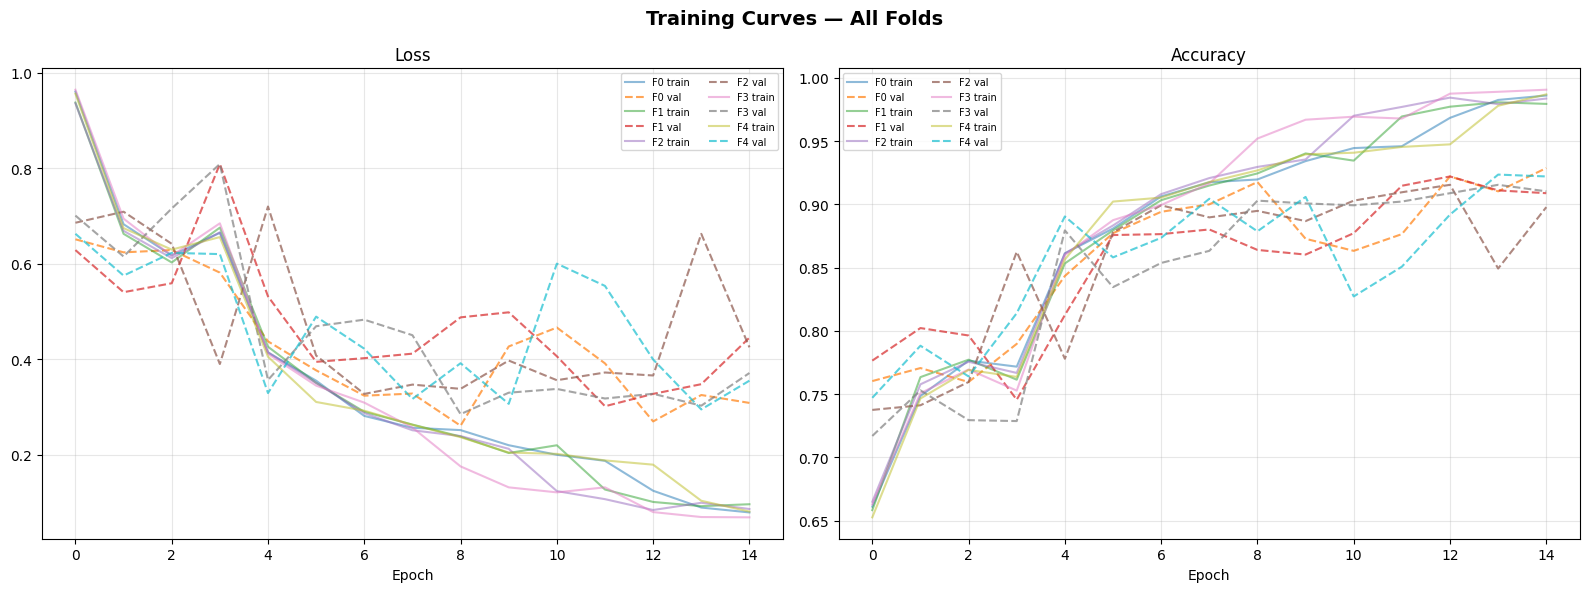

In [12]:
# ============================================================
# 9) TRAINING CURVES (all folds)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for fold_id, h in enumerate(fold_histories):
    axes[0].plot(h["loss"], alpha=0.5, label=f"F{fold_id} train")
    axes[0].plot(h["val_loss"], "--", alpha=0.7, label=f"F{fold_id} val")
    axes[1].plot(h["acc"], alpha=0.5, label=f"F{fold_id} train")
    axes[1].plot(h["val_acc"], "--", alpha=0.7, label=f"F{fold_id} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
plt.suptitle("Training Curves — All Folds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "training_curves_all_folds.png"), dpi=200)
plt.show()



In [13]:
# Rebuild from fold_metrics (which was populated in step 7)
val_accs   = [m["val_acc"]  for m in fold_metrics]
val_losses = [m["val_loss"] for m in fold_metrics]

print(f"Fold val accuracies: {val_accs}")

Fold val accuracies: [0.9286764860153198, 0.9220588207244873, 0.9154411554336548, 0.9154411554336548, 0.9235293865203857]


In [14]:
# ============================================================
# 10) TEST SET EVALUATION — Single Best + Ensemble
# ============================================================
print(f"\n{'='*65}")
print(f"  HELD-OUT TEST SET EVALUATION")
print(f"{'='*65}")

test_ds = make_dataset(X_test, y_test, training=False)

# --- 10a) Ensemble prediction (soft voting) ---
print("\n  Computing ensemble predictions...")
all_probs = []
for i, m in enumerate(fold_models):
    probs = m.predict(test_ds, verbose=0)
    all_probs.append(probs)
    print(f"    Fold {i} predicted")

y_prob_ensemble = np.mean(all_probs, axis=0)
y_pred_ensemble = np.argmax(y_prob_ensemble, axis=1)

# --- 10b) Best single fold ---
best_fold_idx = np.argmax(val_accs)
y_prob_single = all_probs[best_fold_idx]
y_pred_single = np.argmax(y_prob_single, axis=1)

print(f"\n  Best single fold: {best_fold_idx} (val_acc = {val_accs[best_fold_idx]:.4f})")



  HELD-OUT TEST SET EVALUATION

  Computing ensemble predictions...
    Fold 0 predicted
    Fold 1 predicted
    Fold 2 predicted
    Fold 3 predicted
    Fold 4 predicted

  Best single fold: 0 (val_acc = 0.9287)


In [15]:
# ============================================================
# 11) FULL METRICS FUNCTION
# ============================================================
def full_evaluation(y_true, y_prob, y_pred, set_name="Test"):
    """Compute and display all metrics."""
    y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    # Core metrics
    acc         = float(np.mean(y_pred == y_true))
    top3        = float(np.mean([y_true[i] in np.argsort(y_prob[i])[-3:] for i in range(len(y_true))]))
    macro_f1    = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    kappa       = cohen_kappa_score(y_true, y_pred)
    mcc         = matthews_corrcoef(y_true, y_pred)

    try:
        macro_auc    = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
        weighted_auc = roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")
    except:
        macro_auc = weighted_auc = None

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*65}")
    print(f"  {set_name} — Classification Report")
    print(f"{'='*65}")
    print(report)

    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Top-3 Accuracy : {top3:.4f}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print(f"  Cohen's Kappa  : {kappa:.4f}")
    print(f"  MCC            : {mcc:.4f}")
    if macro_auc:
        print(f"  Macro AUC      : {macro_auc:.4f}")
        print(f"  Weighted AUC   : {weighted_auc:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{set_name} — Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_xticklabels(class_names, rotation=45, ha="right")

    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{set_name} — Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_confusion_matrix.png"), dpi=200)
    plt.show()

    # --- ROC Curves ---
    plt.figure(figsize=(10, 8))
    per_class_auc = {}
    for c in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        c_auc = auc(fpr, tpr)
        per_class_auc[class_names[c]] = c_auc
        plt.plot(fpr, tpr, lw=1.5, label=f"{class_names[c]} (AUC={c_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{set_name} — Per-Class ROC Curves")
    plt.legend(loc="lower right", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_roc_curves.png"), dpi=200)
    plt.show()

    # --- Precision-Recall Curves ---
    plt.figure(figsize=(10, 8))
    for c in range(N_CLASSES):
        prec, rec, _ = precision_recall_curve(y_bin[:, c], y_prob[:, c])
        ap = average_precision_score(y_bin[:, c], y_prob[:, c])
        plt.plot(rec, prec, lw=1.5, label=f"{class_names[c]} (AP={ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{set_name} — Precision-Recall Curves")
    plt.legend(loc="lower left", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_pr_curves.png"), dpi=200)
    plt.show()

    # --- Per-class accuracy bar chart ---
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    colors = plt.cm.Set2(np.linspace(0, 1, N_CLASSES))
    plt.figure(figsize=(12, 5))
    bars = plt.bar(class_names, per_class_acc, color=colors, edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, per_class_acc):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.1%}", ha="center", fontsize=9)
    plt.ylim(0, 1.15); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Per-Class Accuracy")
    plt.xticks(rotation=45, ha="right"); plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_per_class_acc.png"), dpi=200)
    plt.show()

    # --- Calibration / ECE ---
    conf = np.max(y_prob, axis=1)
    correct = (y_pred == y_true).astype(int)
    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(conf, bins) - 1
    ECE = 0.0
    N = len(conf)
    bin_acc_list, bin_conf_list = [], []
    for b in range(len(bins) - 1):
        idx = bin_ids == b
        if idx.sum() > 0:
            acc_b = correct[idx].mean()
            conf_b = conf[idx].mean()
            ECE += (idx.sum() / N) * abs(acc_b - conf_b)
            bin_acc_list.append(acc_b)
            bin_conf_list.append(conf_b)
        else:
            bin_acc_list.append(np.nan)
            bin_conf_list.append(np.nan)

    centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect")
    plt.scatter(centers, bin_acc_list, s=50, zorder=5, label="Observed")
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Reliability Diagram (ECE={ECE:.4f})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_calibration.png"), dpi=200)
    plt.show()
    print(f"  ECE            : {ECE:.4f}")

    return {
        "accuracy": acc, "top3_accuracy": top3,
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
        "cohen_kappa": float(kappa), "mcc": float(mcc),
        "macro_auc": float(macro_auc) if macro_auc else None,
        "weighted_auc": float(weighted_auc) if weighted_auc else None,
        "ece": float(ECE),
        "per_class_auc": {k: float(v) for k, v in per_class_auc.items()},
    }




  TEST — Best Single Fold (0)

  Test_SingleBest — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.8683    0.9667    0.9148       150
dyed-resection-margins     0.9627    0.8600    0.9085       150
           esophagitis     0.8400    0.8400    0.8400       150
          normal-cecum     0.9795    0.9533    0.9662       150
        normal-pylorus     0.9740    1.0000    0.9868       150
         normal-z-line     0.8389    0.8333    0.8361       150
                polyps     0.9706    0.8800    0.9231       150
    ulcerative-colitis     0.8963    0.9800    0.9363       150

              accuracy                         0.9142      1200
             macro avg     0.9163    0.9142    0.9140      1200
          weighted avg     0.9163    0.9142    0.9140      1200

  Accuracy       : 0.9142
  Top-3 Accuracy : 0.9967
  Macro F1       : 0.9140
  Weighted F1    : 0.9140
  Cohen's Kappa  : 0.9019
  MCC            : 0.9023

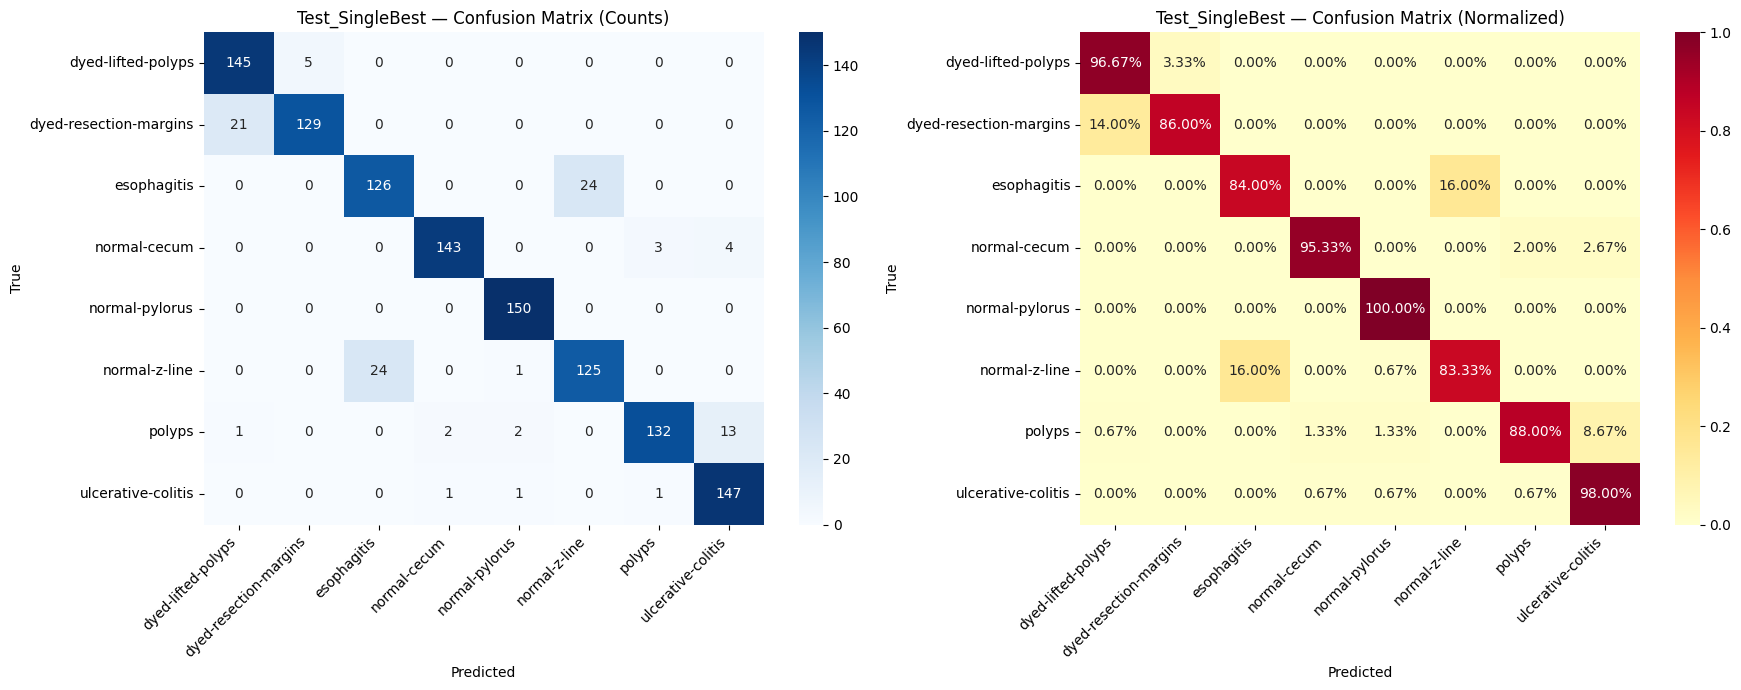

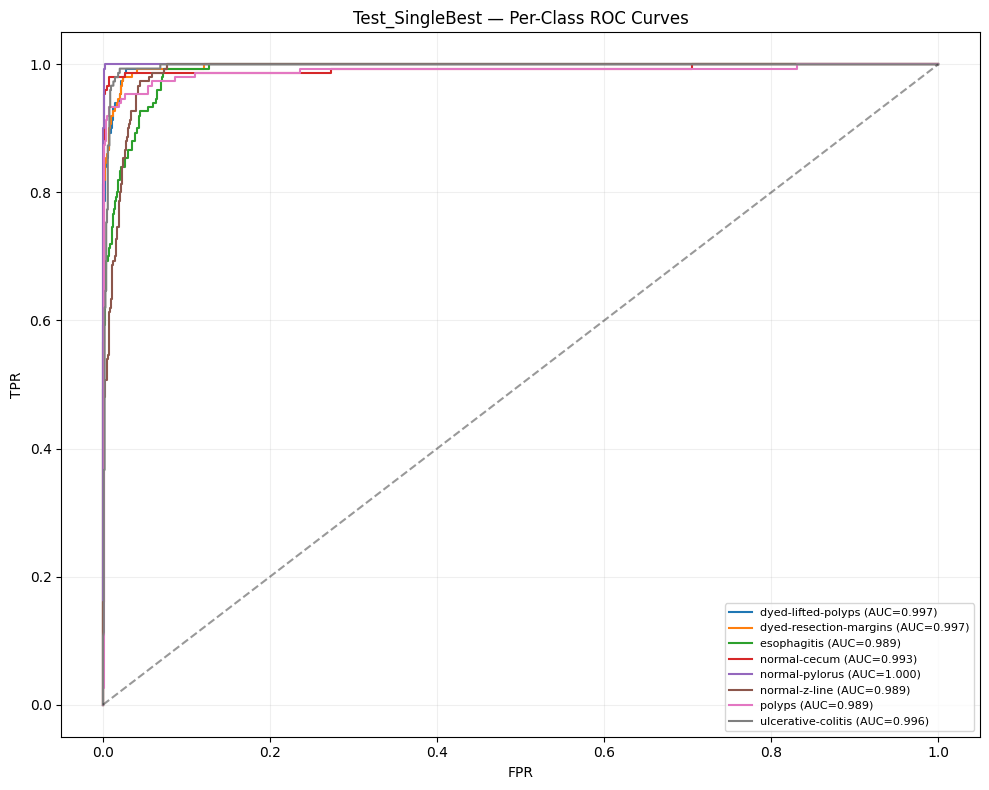

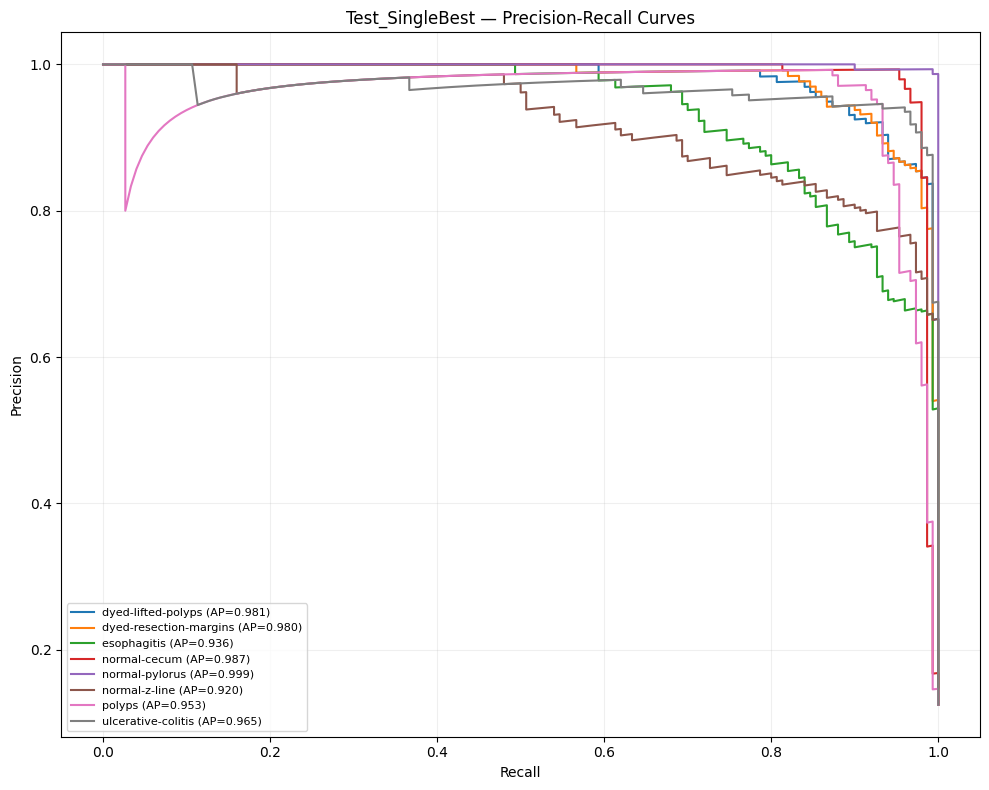

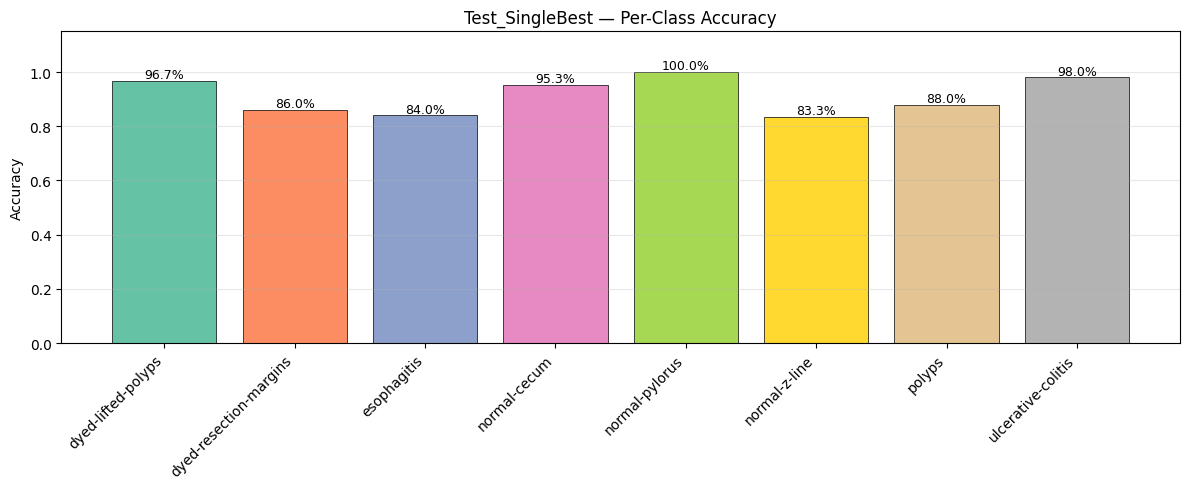

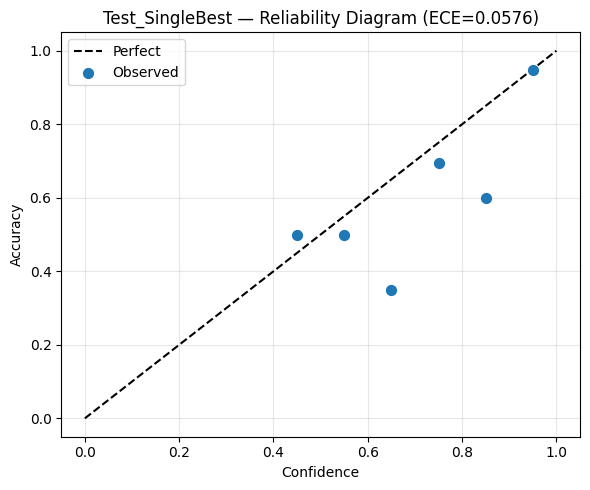

  ECE            : 0.0576

  TEST — Ensemble (5 folds, soft voting)

  Test_Ensemble — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9355    0.9667    0.9508       150
dyed-resection-margins     0.9655    0.9333    0.9492       150
           esophagitis     0.9254    0.8267    0.8732       150
          normal-cecum     0.9931    0.9533    0.9728       150
        normal-pylorus     0.9934    1.0000    0.9967       150
         normal-z-line     0.8434    0.9333    0.8861       150
                polyps     0.9592    0.9400    0.9495       150
    ulcerative-colitis     0.9367    0.9867    0.9610       150

              accuracy                         0.9425      1200
             macro avg     0.9440    0.9425    0.9424      1200
          weighted avg     0.9440    0.9425    0.9424      1200

  Accuracy       : 0.9425
  Top-3 Accuracy : 1.0000
  Macro F1       : 0.9424
  Weighted F1    : 0.9424
  Cohen's Kappa 

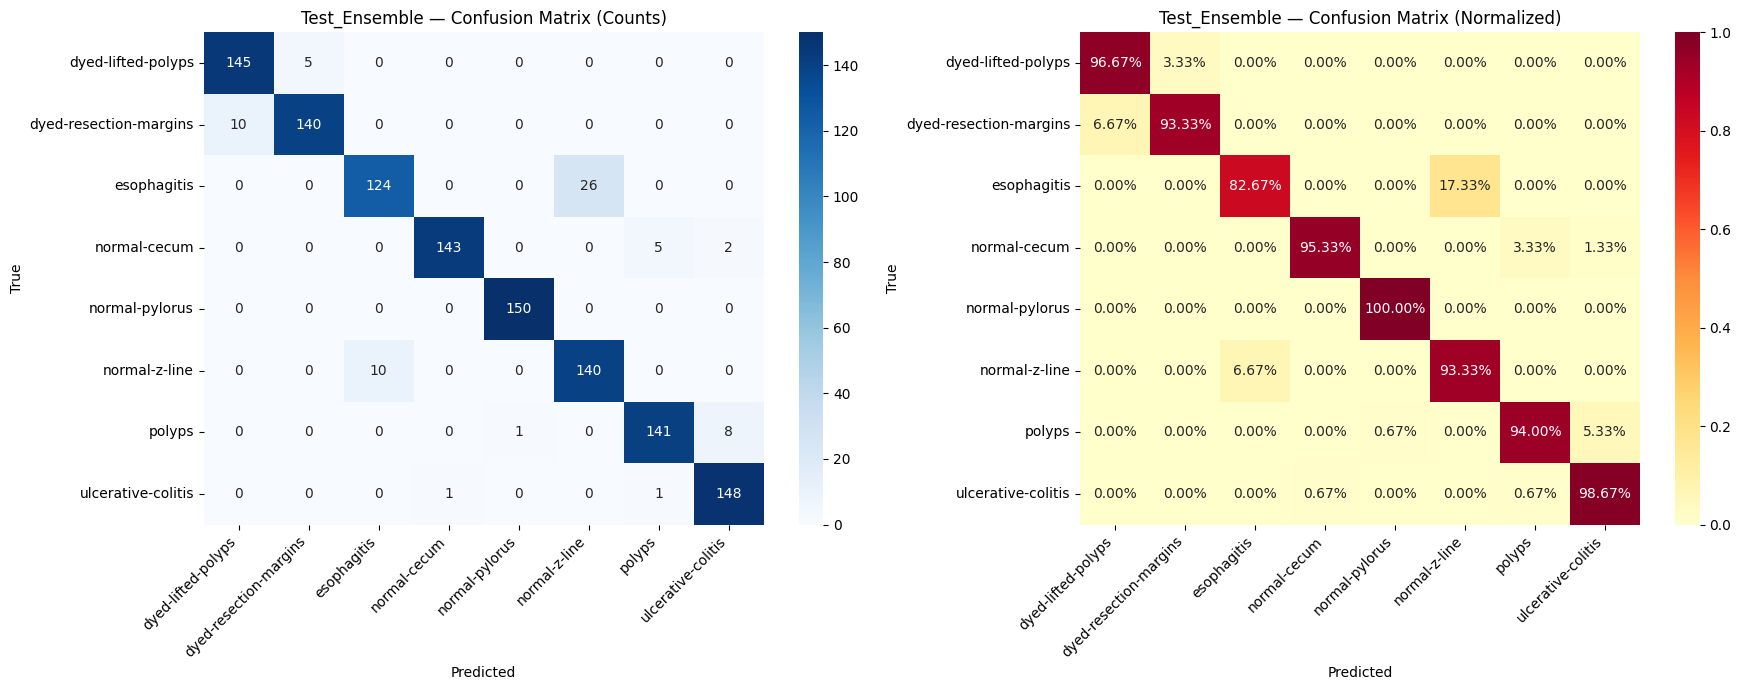

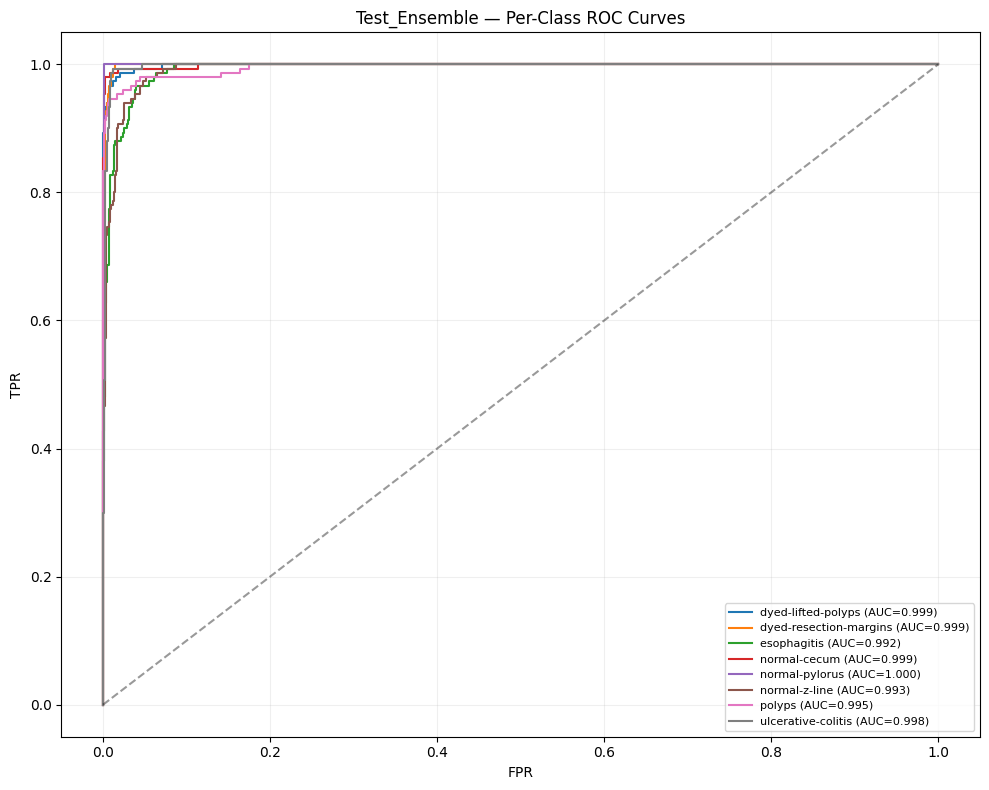

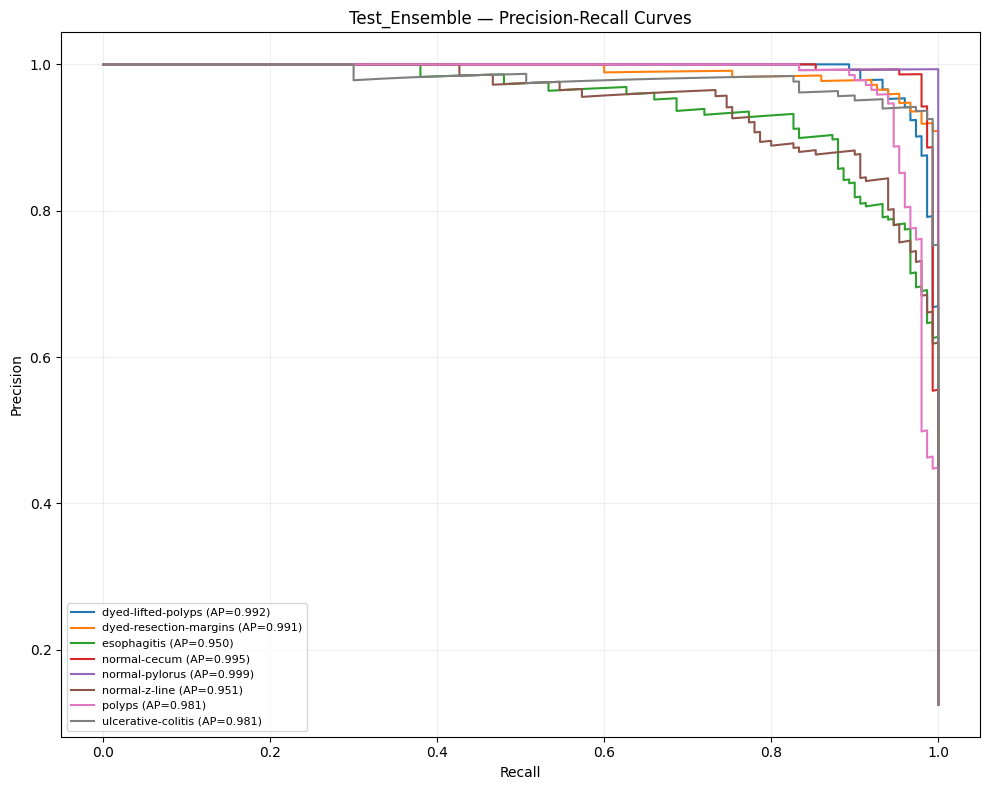

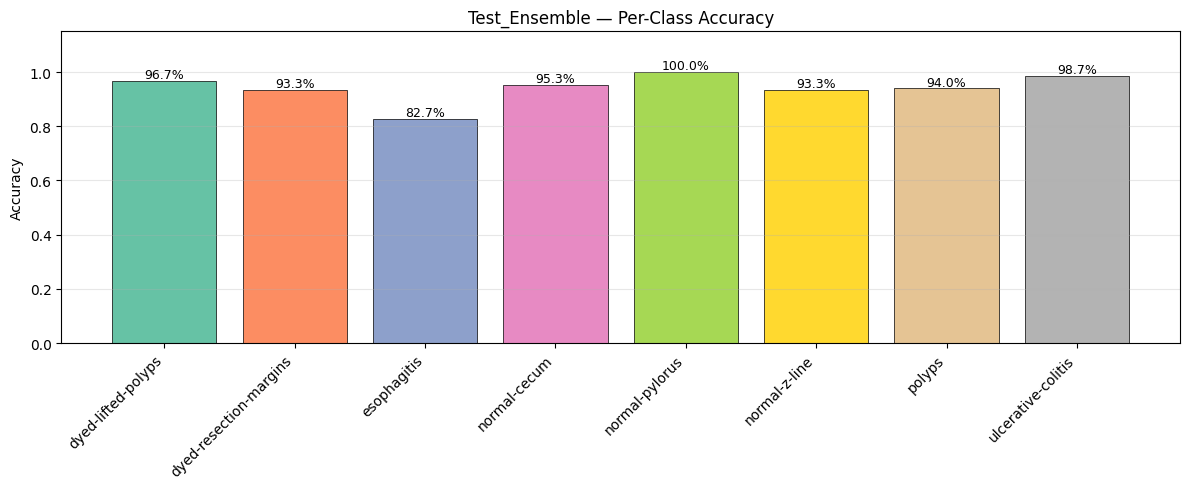

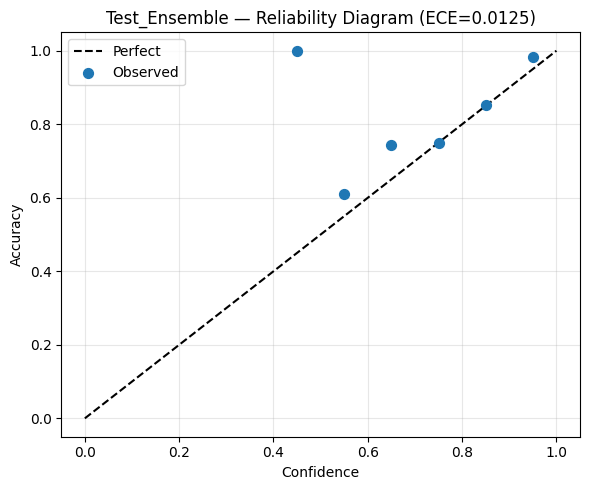

  ECE            : 0.0125


In [16]:
# ============================================================
# 12) RUN EVALUATION
# ============================================================

# Single best fold
print(f"\n{'='*65}")
print(f"  TEST — Best Single Fold ({best_fold_idx})")
print(f"{'='*65}")
single_results = full_evaluation(y_test, y_prob_single, y_pred_single, set_name="Test_SingleBest")

# Ensemble
print(f"\n{'='*65}")
print(f"  TEST — Ensemble ({len(fold_models)} folds, soft voting)")
print(f"{'='*65}")
ensemble_results = full_evaluation(y_test, y_prob_ensemble, y_pred_ensemble, set_name="Test_Ensemble")


In [17]:
# ============================================================
# 13) COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Top-3 Accuracy", "Macro F1", "Weighted F1",
               "Cohen's Kappa", "MCC", "Macro AUC", "Weighted AUC", "ECE"],
    "Single Best": [single_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
    "Ensemble": [ensemble_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
})

print(f"\n{'='*65}")
print(f"  Single Best vs Ensemble")
print(f"{'='*65}")
print(comparison.to_string(index=False))
comparison.to_csv(os.path.join(CFG.OUTPUT_DIR, "comparison.csv"), index=False)



  Single Best vs Ensemble
        Metric  Single Best  Ensemble
      Accuracy     0.914167  0.942500
Top-3 Accuracy     0.996667  1.000000
      Macro F1     0.913980  0.942411
   Weighted F1     0.913980  0.942411
 Cohen's Kappa     0.901905  0.934286
           MCC     0.902252  0.934535
     Macro AUC     0.993833  0.996837
  Weighted AUC     0.993833  0.996837
           ECE     0.057577  0.012511


In [18]:
# ============================================================
# 14) SAVE EXPERIMENT SUMMARY
# ============================================================
summary = {
    "model": "ConvNeXt-Tiny",
    "preprocessing": "CLAHE + Gaussian + Bilateral",
    "dataset": "Kvasir v2",
    "img_size": list(CFG.IMG_SIZE),
    "batch_size": CFG.BATCH_SIZE,
    "epochs_warmup": CFG.EPOCHS_WARMUP,
    "epochs_finetune": CFG.EPOCHS_FINETUNE,
    "lr_warmup": CFG.LR_WARMUP,
    "lr_finetune": CFG.LR_FINETUNE,
    "n_folds": CFG.N_SPLITS,
    "test_size": CFG.TEST_SIZE,
    "fold_val_accuracies": val_accs,
    "mean_val_acc": float(np.mean(val_accs)),
    "std_val_acc": float(np.std(val_accs)),
    "best_single_fold": int(best_fold_idx),
    "test_single_best": {k: v for k, v in single_results.items() if k != "per_class_auc"},
    "test_ensemble": {k: v for k, v in ensemble_results.items() if k != "per_class_auc"},
}

with open(os.path.join(CFG.OUTPUT_DIR, "experiment_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)

with open(os.path.join(CFG.OUTPUT_DIR, "classification_report_ensemble.txt"), "w") as f:
    f.write(classification_report(y_test, y_pred_ensemble, target_names=class_names, digits=4))


print(f"\n{'='*65}")
print(f"  ALL DONE — Results saved to '{CFG.OUTPUT_DIR}/'")
print(f"{'='*65}")
print(f"\n  Files:")
print(f"    splits/                         — reproducible train/val/test CSVs")
print(f"    best_fold*.h5                   — model weights per fold")
print(f"    log_fold*.csv                   — training logs per fold")
print(f"    training_curves_all_folds.png   — loss/acc curves")
print(f"    test_*_confusion_matrix.png     — confusion matrices")
print(f"    test_*_roc_curves.png           — ROC curves")
print(f"    test_*_pr_curves.png            — precision-recall curves")
print(f"    test_*_per_class_acc.png        — per-class accuracy bars")
print(f"    test_*_calibration.png          — reliability diagrams")
print(f"    comparison.csv                  — single vs ensemble table")
print(f"    experiment_summary.json         — complete experiment config + results")
print(f"\n  Key Results:")
print(f"    CV Mean Acc      : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"    Test Acc (single): {single_results['accuracy']:.4f}")
print(f"    Test Acc (ens.)  : {ensemble_results['accuracy']:.4f}")
print(f"    Test Macro AUC   : {ensemble_results.get('macro_auc', 'N/A')}")


  ALL DONE — Results saved to '/kaggle/working/convnext_results/'

  Files:
    splits/                         — reproducible train/val/test CSVs
    best_fold*.h5                   — model weights per fold
    log_fold*.csv                   — training logs per fold
    training_curves_all_folds.png   — loss/acc curves
    test_*_confusion_matrix.png     — confusion matrices
    test_*_roc_curves.png           — ROC curves
    test_*_pr_curves.png            — precision-recall curves
    test_*_per_class_acc.png        — per-class accuracy bars
    test_*_calibration.png          — reliability diagrams
    comparison.csv                  — single vs ensemble table
    experiment_summary.json         — complete experiment config + results

  Key Results:
    CV Mean Acc      : 0.9210 ± 0.0051
    Test Acc (single): 0.9142
    Test Acc (ens.)  : 0.9425
    Test Macro AUC   : 0.9968373015873017
